# Customer Churn Analysis using Python & SQLite

## Project Overview

Customer churn is one of the most important business metrics because retaining existing customers is generally more cost-effective than acquiring new ones. This project analyzes customer data stored in a SQLite database to identify churn patterns, understand the factors influencing customer attrition, and generate business recommendations using data analysis and visualization techniques.

### Objectives

- Connect and query data from a SQLite database.
- Clean and preprocess customer data.
- Perform exploratory data analysis (EDA).
- Visualize customer churn patterns.
- Identify key factors associated with customer churn.
- Provide actionable business recommendations based on the analysis.

### Tools & Technologies

- Python
- Pandas
- NumPy
- SQLite
- Matplotlib
- Seaborn
- Jupyter Notebook

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(r"C:\Users\kambl\customer_churn_1000.db")
print("Connected successfully!")

Connected successfully!


In [4]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(r"C:\Users\kambl\customer_churn_1000.db")

sql_query = """
SELECT name
FROM sqlite_master
WHERE type='table'
"""

tables = pd.read_sql(sql_query, conn)

print(tables)

# Create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()

              name
0      db_customer
1  db_subscription
2       db_support
Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [5]:
# Print table names and coloumns names
conn = sqlite3.connect(r"C:\Users\kambl\customer_churn_1000.db")

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # get column info
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

conn.close()    


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [6]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,CUST0001,Nathaniel Dara,India,Karnataka,Male,1977-11-18,Reading,544689.0
1,CUST0002,Aryan Mahajan,India,Punjab,Male,1958-02-03,Sports,692879.0
2,CUST0003,Odika Sarna,India,Delhi,Female,1971-06-30,Reading,123460.0
3,CUST0004,Falak Badal,India,Delhi,Female,1973-05-15,Sports,421677.0
4,CUST0005,Yash Dani,India,Punjab,Male,1996-06-24,Travel,498875.0


In [7]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   customerid  1000 non-null   str    
 1   name        1000 non-null   str    
 2   country     1000 non-null   str    
 3   state       1000 non-null   str    
 4   gender      1000 non-null   str    
 5   dob         1000 non-null   str    
 6   interests   1000 non-null   str    
 7   pincode     1000 non-null   float64
dtypes: float64(1), str(7)
memory usage: 62.6 KB


In [8]:
#data cleaning


In [9]:
df_db_customer.rename(columns={'name': 'customer_name'}, inplace=True)
df_db_customer.drop(df_db_customer.columns[-2:], axis=1, inplace=True)

In [10]:
df_db_customer.columns

Index(['customerid', 'customer_name', 'country', 'state', 'gender', 'dob'], dtype='str')

In [11]:
for col in df_db_customer.columns:
    print(repr(col))

'customerid'
'customer_name'
'country'
'state'
'gender'
'dob'


In [12]:
df_db_customer.columns = df_db_customer.columns.str.strip()

In [13]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [14]:
print(df_db_customer.columns.tolist())

['customerid', 'customer_name', 'country', 'state', 'gender', 'dob']


In [15]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [16]:
df_db_customer['gender'] = df_db_customer['gender'].replace({
    'Men': 'Male',
    'Women': 'Female'
})

In [17]:
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [18]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [19]:
df_db_customer


,customerid,customer_name,country,state,gender,dob
0,CUST0001,Nathaniel Dara,India,Karnataka,Male,1977-11-18
1,CUST0002,Aryan Mahajan,India,Punjab,Male,1958-02-03
2,CUST0003,Odika Sarna,India,Delhi,Female,1971-06-30
3,CUST0004,Falak Badal,India,Delhi,Female,1973-05-15
4,CUST0005,Yash Dani,India,Punjab,Male,1996-06-24
...,...,...,...,...,...,...
995,CUST0996,Yashasvi Shukla,India,Rajasthan,Female,1956-02-21
996,CUST0997,Pranit Shenoy,India,Delhi,Male,1957-02-18
997,CUST0998,Yatin Oommen,India,Tamil Nadu,Male,1978-04-03
998,CUST0999,Avni Wable,India,Tamil Nadu,Female,1970-02-21


In [20]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,CUST0001,2026-06-28,Streaming,2027-06-28,Basic,Annual,2027-03-01,Competitor,1524.0,68580,76
1,CUST0002,2021-11-01,Mobile,2022-11-01,Standard,Monthly,2022-01-19,Competitor,1341.0,46935,82
2,CUST0003,2022-05-04,Streaming,2023-05-04,Premium,Annual,2022-10-22,Price,1678.0,63764,95
3,CUST0004,2022-08-09,Mobile,2023-08-09,Basic,Annual,NaN,NaN,688.0,24080,13
4,CUST0005,2023-05-11,Internet,2024-05-10,Standard,Monthly,NaN,NaN,2285.0,107395,22


In [21]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               1000 non-null   str    
 1   subscription_start_date  1000 non-null   str    
 2   subscription_type        1000 non-null   str    
 3   renewal_date             1000 non-null   str    
 4   plan_type                1000 non-null   str    
 5   contract_type            1000 non-null   str    
 6   cancellation_date        497 non-null    str    
 7   cancellation_reason      497 non-null    str    
 8   monthly_charges          1000 non-null   float64
 9   cltv                     1000 non-null   int64  
 10  churn_score              1000 non-null   int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 86.1 KB


In [22]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()                                                               

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               1000 non-null   str           
 1   subscription_start_date  1000 non-null   datetime64[us]
 2   subscription_type        1000 non-null   str           
 3   renewal_date             1000 non-null   datetime64[us]
 4   plan_type                1000 non-null   str           
 5   contract_type            1000 non-null   str           
 6   cancellation_date        497 non-null    datetime64[us]
 7   cancellation_reason      497 non-null    str           
 8   monthly_charges          1000 non-null   float64       
 9   cltv                     1000 non-null   int64         
 10  churn_score              1000 non-null   int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 86.1 KB


In [23]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,CUST0001,2026-07-13,N,3,4.18,Pending
1,CUST0002,2025-08-31,Y,1,1.67,Pending
2,CUST0005,2026-01-31,Y,1,3.22,Satisfied
3,CUST0006,2025-09-28,N,5,3.22,Not Satisfied
4,CUST0008,2023-05-20,Y,2,1.85,Issue Closed


In [24]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customerid      740 non-null    str    
 1   complaint_date  740 non-null    str    
 2   escalations     740 non-null    str    
 3   csat_score      740 non-null    int64  
 4   col_1           740 non-null    float64
 5   comment         740 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 34.8 KB


In [25]:
df_db_support.drop(df_db_support.columns[-2:], axis=1, inplace=True)
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerid      740 non-null    str  
 1   complaint_date  740 non-null    str  
 2   escalations     740 non-null    str  
 3   csat_score      740 non-null    int64
dtypes: int64(1), str(3)
memory usage: 23.3 KB


In [26]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      740 non-null    str           
 1   complaint_date  740 non-null    datetime64[us]
 2   escalations     740 non-null    str           
 3   csat_score      740 non-null    int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 23.3 KB


In [27]:
df_db_subscription['churn flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [28]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn flag
0,CUST0001,2026-06-28,Streaming,2027-06-28,Basic,Annual,2027-03-01,Competitor,1524.0,68580,76,1
1,CUST0002,2021-11-01,Mobile,2022-11-01,Standard,Monthly,2022-01-19,Competitor,1341.0,46935,82,1
2,CUST0003,2022-05-04,Streaming,2023-05-04,Premium,Annual,2022-10-22,Price,1678.0,63764,95,1
3,CUST0004,2022-08-09,Mobile,2023-08-09,Basic,Annual,NaT,NaN,688.0,24080,13,0
4,CUST0005,2023-05-11,Internet,2024-05-10,Standard,Monthly,NaT,NaN,2285.0,107395,22,0


In [29]:
#first fix supportable duplicate then merge
df=(df_db_subscription.merge(df_db_customer,on='customerid',how = 'left')
                  .merge(df_db_support,on='customerid',how = 'left'))

# Data Cleaning

### Steps Performed
- Renamed column names.
- Removed unnecessary columns (`interests`, `pincode`,`comments`).
- Converted `dob` to datetime.
- Standardized gender values.
- Fixed missing values.
- Added columns like churn flag
- Merged for better view

### Insights
- Data quality improved after cleaning.
- Standardized values ensured consistent analysis.
- Removing unnecessary columns simplified the dataset.
- Missing values were handled to improve analysis accuracy.

In [30]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,CUST0001,2026-06-28,Streaming,2027-06-28,Basic,Annual,2027-03-01,Competitor,1524.0,68580,76,1,Nathaniel Dara,India,Karnataka,Male,1977-11-18,2026-07-13,N,3.0
1,CUST0002,2021-11-01,Mobile,2022-11-01,Standard,Monthly,2022-01-19,Competitor,1341.0,46935,82,1,Aryan Mahajan,India,Punjab,Male,1958-02-03,2025-08-31,Y,1.0
2,CUST0003,2022-05-04,Streaming,2023-05-04,Premium,Annual,2022-10-22,Price,1678.0,63764,95,1,Odika Sarna,India,Delhi,Female,1971-06-30,NaT,NaN,NaN
3,CUST0004,2022-08-09,Mobile,2023-08-09,Basic,Annual,NaT,NaN,688.0,24080,13,0,Falak Badal,India,Delhi,Female,1973-05-15,NaT,NaN,NaN
4,CUST0005,2023-05-11,Internet,2024-05-10,Standard,Monthly,NaT,NaN,2285.0,107395,22,0,Yash Dani,India,Punjab,Male,1996-06-24,2026-01-31,Y,1.0


In [31]:
df_db_subscription.shape

(1000, 12)

In [32]:
df.shape

(1000, 20)

In [33]:
df_db_subscription['customerid'].nunique()

1000

In [34]:
df_db_customer['customerid'].nunique()

1000

In [35]:
df_db_support['customerid'].nunique()

740

In [36]:
df_db_support['customerid'].size

740

In [37]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,CUST0001,2026-07-13,N,3
1,CUST0002,2025-08-31,Y,1
2,CUST0005,2026-01-31,Y,1
3,CUST0006,2025-09-28,N,5
4,CUST0008,2023-05-20,Y,2
...,...,...,...,...
735,CUST0996,2026-04-03,Y,3
736,CUST0997,2024-03-18,Y,3
737,CUST0998,2022-11-01,N,4
738,CUST0999,2024-03-14,Y,2


In [38]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [39]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [40]:
df_db_support['customerid'].size

740

In [41]:
# merge df
df=(df_db_subscription
                  .merge(df_db_customer,on='customerid',how = 'left')
                  .merge(df_db_support,on='customerid',how = 'left'))

In [42]:
df.shape

(1000, 21)

In [43]:
# data analysis

In [44]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [45]:
#churn rate
churn_rate = df['churn flag'].mean()*100
print("Churn Rate = ",round(churn_rate,2),"%")

Churn Rate =  49.7 %


In [46]:
# retention rate
Retention_Rate = 100 - churn_rate
print("Retention_Rate = ",round(Retention_Rate,2),"%")

Retention_Rate =  50.3 %


In [68]:
# churn by plan type
churn_by_plan = df.groupby('plan_type')['churn flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')
print( churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           49.12
1   Premium           48.95
2  Standard           51.08


In [69]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'csat_score', 'complaint_count', 'tenure_days',
       'escalations', 'churn_risk'],
      dtype='str')

In [70]:
#average revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU=',round(arpu,2))

ARPU= 1392.09


In [71]:
# avg customer tenure
today = pd.Timestamp.today()
df['tenure_days']=np.where(
                df['cancellation_date'].notna(),
    (df['cancellation_date']-df['subscription_start_date']).dt.days,
    (today-df['subscription_start_date']).dt.days
)
avg_tenure = df['tenure_days'].mean()
print("Avg tenure (Days)=",round(avg_tenure),0)

Avg tenure (Days)= 566 0


In [72]:
# revenue at risk - revenue last from churned user
revenue_at_risk = df.loc[df['churn flag']==1,'monthly_charges' ].sum()
print("Revenue at Risk(rs K)=",revenue_at_risk)

Revenue at Risk(rs K)= 692293.0


In [73]:
# excalation rate
escalation_rate = (df['escalations']=='Y').mean()*100
print('Escalations Rate = ',round(escalation_rate,2),"%")

Escalations Rate =  0.0 %


In [75]:
#avg complaint per user
avg_complaint = df['complaint_count'].sum()/df['customerid'].nunique()
print("Avg Complaint Per User =",round(avg_complaint,2))

Avg Complaint Per User = 0.74


In [76]:
# Remove the incorrect column
df.drop(columns=['escalations'], inplace=True)

# Merge the correct escalation values
df = df.merge(
    df_db_support[['customerid', 'escalations']],
    on='customerid',
    how='left'
)

In [77]:
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0)

In [78]:
df['escalations'].value_counts()

escalations
0    615
1    385
Name: count, dtype: int64

In [79]:
#correlation
corr_df = df[['escalations', 'churn flag']].dropna()

correlation = corr_df['escalations'].corr(corr_df['churn flag'])

print("Correlation between escalation vs churn =", round(correlation, 2))

Correlation between escalation vs churn = -0.03


In [80]:
df['churn_score'].head()

0    76
1    82
2    95
3    13
4    22
Name: churn_score, dtype: int64

In [81]:
#churn risk - create a column using a column existing col
conditions =[
              (df['churn_score']<50),
              (df['churn_score']>=50) & (df['churn_score']<70),
              (df['churn_score']>=70)    
]
choices = ['low','med','high']
df['churn_risk']=np.select(conditions,choices,default='unknown')

In [82]:
df_visual= df.copy()

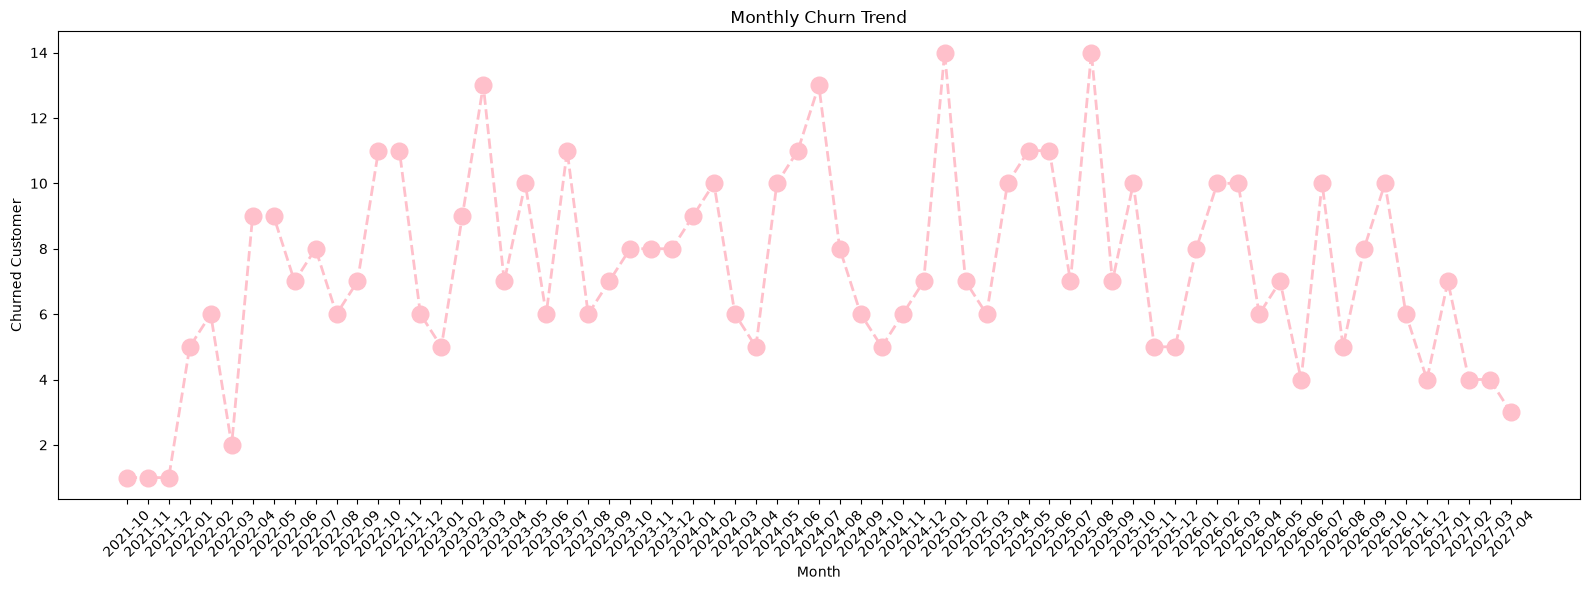

In [83]:
# monthly churn trend (time series KPI)
df_visual['cancellation month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend =df_visual[df_visual['churn flag']==1].groupby('cancellation month').size()

plt.figure(figsize=(16,6
                   ))
plt.plot(churn_trend.index.astype(str),churn_trend.values,color='pink',marker='o',linestyle='dashed',linewidth=2,markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customer')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##  Insights

- The monthly churn trend shows noticeable fluctuations, indicating that customer churn varies across different months.
- The highest churn recorded in a single month is **14 customers**, while the lowest is **1 customer**.
- Several months experienced sharp spikes in churn, suggesting periods of increased customer cancellations.
- Overall, there is no consistent upward or downward trend, indicating that churn remains relatively stable over the observed period.

###  Business Recommendation

- Investigate the reasons behind the high-churn months by analyzing customer complaints, subscription plans, and support interactions.
- Introduce targeted customer retention campaigns before months that historically experience higher churn.

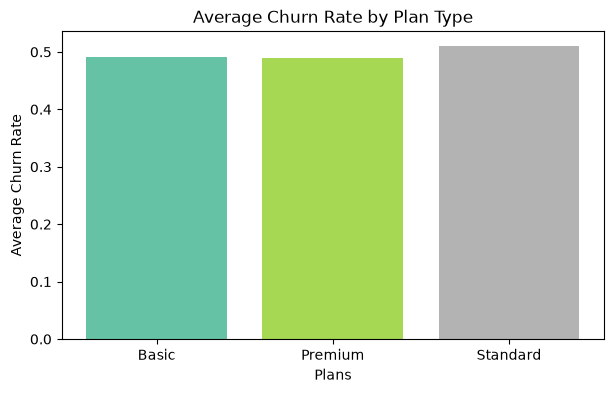

In [84]:
# Churn by plan type
churn_plan =df_visual.groupby('plan_type')['churn flag'].mean()
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index,churn_plan.values,color= colors)
plt.title('Average Churn Rate by Plan Type')
plt.xlabel('Plans')
plt.ylabel('Average Churn Rate')
plt.show()

##  Insights

- The average churn rate is similar across all three plan types, indicating that no single plan has a significantly lower churn rate.
- The **Standard** plan shows the highest average churn rate among the three plans.
- The **Basic** and **Premium** plans have nearly identical churn rates.
- These results suggest that plan type alone may not be the primary factor influencing customer churn.

###  Business Recommendation

- Analyze additional factors such as contract type, customer satisfaction (CSAT), monthly charges, and complaint history to better understand the reasons behind customer churn.
- Customers on the Standard plan can be monitored more closely for early signs of churn.

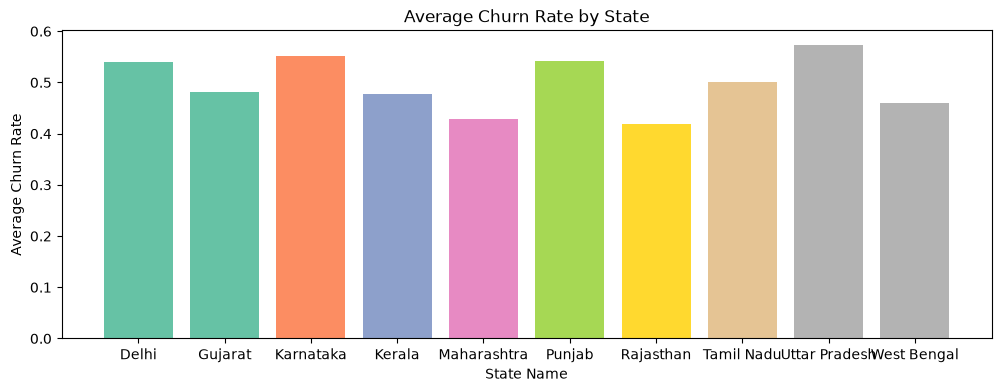

In [85]:
# Churn by state type
churn_plan =df_visual.groupby('state')['churn flag'].mean()
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(12,4))
plt.bar(churn_plan.index,churn_plan.values,color= colors)
plt.title('Average Churn Rate by State')
plt.xlabel('State Name')
plt.ylabel('Average Churn Rate')
plt.show()

##  Insights

- The average churn rate varies slightly across different states.
- Uttar Pradesh records the highest average churn rate among the states in the dataset.
- Rajasthan and Maharashtra have comparatively lower churn rates.
- The differences between states are relatively small, suggesting that geographical location alone is not the primary driver of customer churn.

### Business Recommendation

- Conduct a detailed analysis of high-churn states to identify possible factors such as customer support quality, pricing, or regional preferences.
- Implement targeted customer retention strategies in states with relatively higher churn rates.

In [86]:

import warnings
warnings.filterwarnings("ignore")

In [87]:
df_visual['churn_risk'].unique()

<StringArray>
['high', 'low']
Length: 2, dtype: str

In [88]:
df_encoded = df_visual[['plan_type',
                        'contract_type',
                        'churn_score',
                        'churn flag',
                        'churn_risk',
                        'escalations']].copy()

order_mappings = {
    'plan_type': ['Basic', 'Premium', 'Standard'],
    'contract_type': ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(
        df_encoded[col],
        categories=order,
        ordered=True
    ).codes

In [89]:
 df_visual[['plan_type','contract_type','churn_score','churn flag','churn_risk','escalations']].head()

,plan_type,contract_type,churn_score,churn flag,churn_risk,escalations
0,Basic,Annual,76,1,high,0
1,Standard,Monthly,82,1,high,1
2,Premium,Annual,95,1,high,0
3,Basic,Annual,13,0,low,0
4,Standard,Monthly,22,0,low,1


In [90]:
df_encoded.head()


,plan_type,contract_type,churn_score,churn flag,churn_risk,escalations
0,0,1,76,1,2,0
1,2,0,82,1,2,1
2,1,1,95,1,2,0
3,0,1,13,0,0,0
4,2,0,22,0,0,1


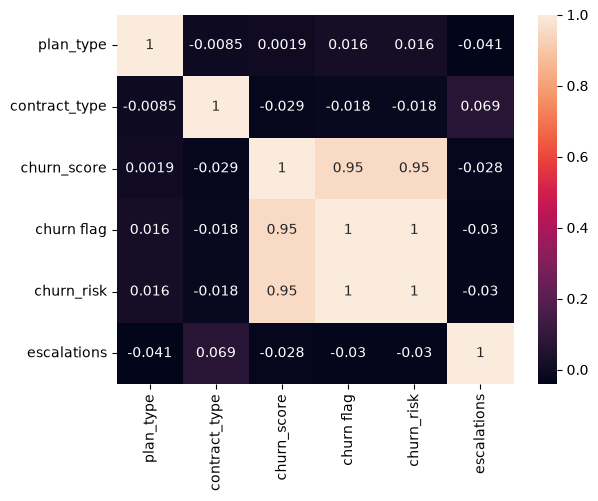

In [91]:
#Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)
plt.show()

##  Insights

- **Churn Score** has a very strong positive correlation (**0.95**) with the **Churn Flag**, indicating that higher churn scores are strongly associated with customers leaving.
- **Churn Risk** is perfectly correlated (**1.00**) with the **Churn Flag**, suggesting that the churn risk category is directly derived from or closely aligned with the churn outcome.
- **Plan Type**, **Contract Type**, and **Escalations** show very weak correlations with churn, indicating that these variables alone are not strong predictors of customer churn.
- Overall, the heatmap suggests that **Churn Score** is the most influential feature for identifying customers who are likely to churn.

###  Business Recommendation

- Prioritize customers with high churn scores for retention campaigns.
- Develop predictive models using churn score and other relevant customer attributes to identify at-risk customers early.
- Explore additional features, such as customer usage patterns or support history, to improve churn prediction accuracy.

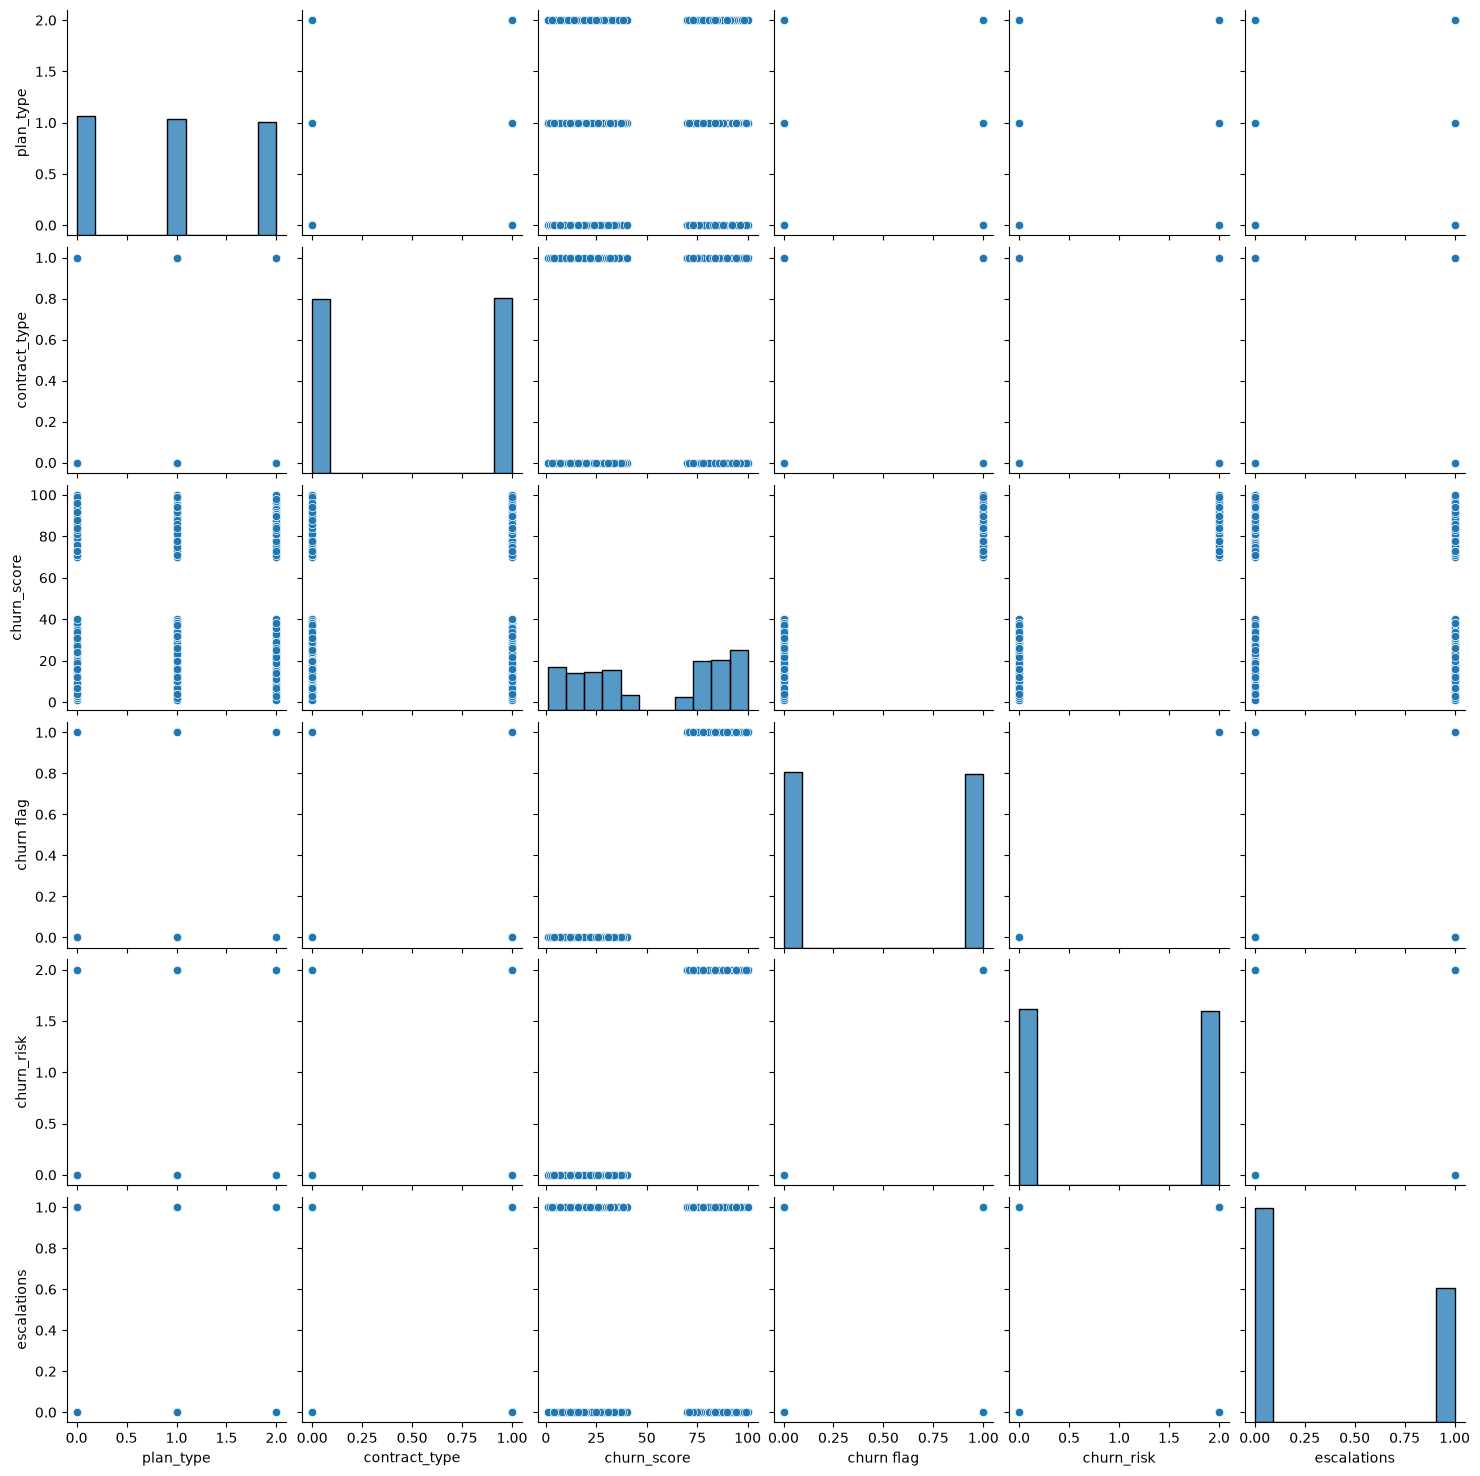

In [92]:
#pairplot - relationship in dataset

sns.pairplot(df_encoded)
plt.show()

## Insights

- The pair plot provides an overview of the relationships between all selected numerical and categorical variables.
- Customers with higher **churn scores** are more likely to belong to the churned category.
- Most variable pairs show weak or no clear linear relationship, indicating that multiple factors contribute to customer churn.
- The distributions help identify patterns, clusters, and potential outliers that may require further investigation.

### Business Recommendation

- Focus on variables such as **Churn Score** and **Churn Risk**, as they show stronger associations with customer churn.
- Combine multiple customer attributes rather than relying on a single factor when predicting churn.

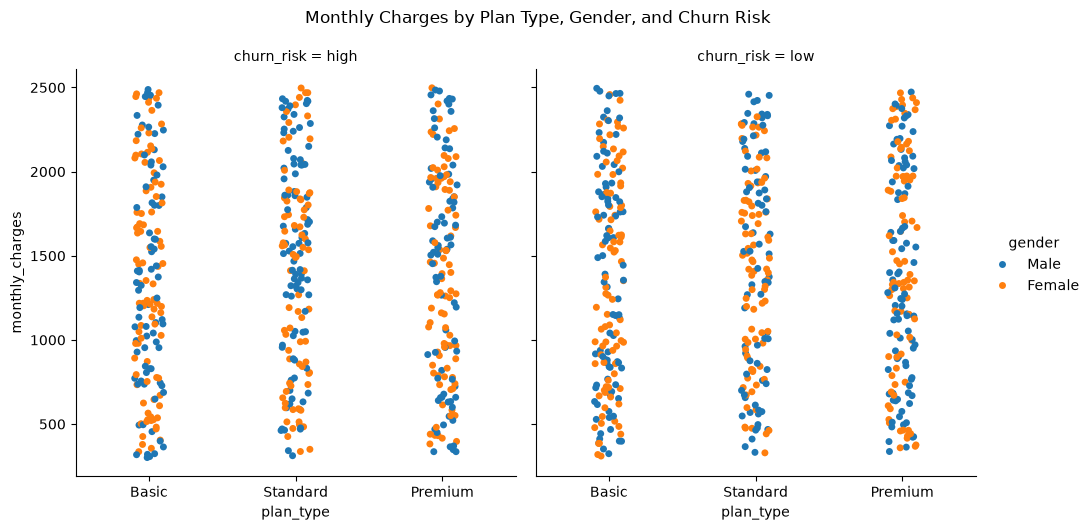

In [94]:
# catlpot/fcegrid plot

g = sns.catplot(
    data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk'
)

g.fig.suptitle("Monthly Charges by Plan Type, Gender, and Churn Risk", y=1.05)

plt.show()

##  Insights

- Monthly charges vary across all three plan types for both high-risk and low-risk customers.
- Male and female customers show similar monthly charge distributions, indicating that gender has little impact on pricing.
- High-risk and low-risk customers are present across all plan types, suggesting that churn risk is not determined by plan type alone.
- Customers with both low and high monthly charges appear in each churn risk category, indicating that monthly charges alone are not a strong predictor of churn.

###  Business Recommendation

- Analyze additional factors such as customer complaints, contract type, and churn score along with monthly charges to better understand churn risk.
- Develop personalized retention strategies based on multiple customer characteristics rather than relying on plan type or monthly charges alone.

In [101]:
#pivot table


In [102]:
pd.pivot_table(
          df_visual,
          index='plan_type',
          values=['monthly_charges','customerid','churn flag']  ,   
          aggfunc = {
              'monthly_charges' : 'sum',
              'customerid' : 'nunique',
              'churn flag' : 'mean'
          } 

    
)


,churn flag,customerid,monthly_charges
plan_type,,,
Basic,0.491228,342,462989.0
Premium,0.489489,333,463682.0
Standard,0.510769,325,465422.0


In [103]:
pd.pivot_table(
    df_visual,
    values='churn flag',
    index='plan_type',
    aggfunc='mean'
)

,churn flag
plan_type,
Basic,0.491228
Premium,0.489489
Standard,0.510769


#  Final Conclusion

This project analyzed customer churn data using Python, SQLite, Pandas, Matplotlib, and Seaborn to understand the factors influencing customer retention. The dataset was cleaned, transformed, and explored through various visualizations.

The analysis showed that churn rates vary across different customer segments, with churn score demonstrating the strongest relationship with customer churn. Monthly churn trends fluctuated over time without a clear long-term increase or decrease, while plan type and state showed only moderate differences in churn behavior. Customer support metrics and satisfaction scores provided additional insights into customer retention.

Overall, the project demonstrates how data analysis can help businesses identify churn patterns and support data-driven decision-making to improve customer retention.

#  Business Recommendations

- Monitor customers with high churn scores and proactively offer retention incentives.
- Improve customer support response time and reduce complaint escalations to enhance customer satisfaction.
- Investigate the reasons behind higher churn during peak months and implement targeted retention campaigns.
- Encourage customers to choose long-term subscription plans where appropriate to improve retention.
- Regularly monitor churn trends using dashboards to identify changes in customer behavior at an early stage.
- Use predictive analytics to identify high-risk customers and personalize retention strategies.

#  Future Scope

This project can be further enhanced by:

- Building machine learning models to predict customer churn.
- Developing an interactive Power BI or Tableau dashboard for real-time business reporting.
- Including additional customer behavior variables such as product usage, login frequency, and payment history.
- Performing customer segmentation to design personalized retention strategies.
- Deploying the churn prediction model as a web application using Streamlit or Flask.